# Decision Trees

----

In [152]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.tree import export_text, plot_tree, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import PartialDependenceDisplay

## Prepare data

In [153]:
df = pd.read_csv("../data/GamingStudy_data_clean.csv")
df.head()

,SWL1,SWL2,SWL3,SWL4,SWL5,Hours,streams,SPIN1,SPIN2,SPIN3,...,Work_Unknown,Degree_High school diploma (or equivalent),Degree_Master (or equivalent),"Degree_Ph.D., Psy. D., MD (or equivalent)",Degree_Unknown,Playstyle_Offline Multiplayer,Playstyle_Other,Playstyle_Real Life Friends,Playstyle_Singleplayer,Playstyle_Strangers
0,7,7,7,5,7,25.0,2.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,6,6,6,3,5,5.0,5.0,2.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,1
2,5,2,6,7,6,9.0,2.0,2.0,2.0,2.0,...,0,1,0,0,0,0,0,1,0,0
3,2,4,6,6,3,7.0,4.0,0.0,1.0,3.0,...,0,0,1,0,0,0,0,0,0,1
4,2,2,1,3,2,25.0,35.0,0.0,2.0,1.0,...,0,1,0,0,0,0,0,0,0,1


In [154]:
df.shape

(10772, 60)

In [155]:
# define target variable
y = df["GAD_T"]

# define feature variables (remove GADE yes or no?) (keep only SPIN_T and SWL_T?)
X = df.drop("GAD_T", axis=1)

X.head()

,SWL1,SWL2,SWL3,SWL4,SWL5,Hours,streams,SPIN1,SPIN2,SPIN3,...,Work_Unknown,Degree_High school diploma (or equivalent),Degree_Master (or equivalent),"Degree_Ph.D., Psy. D., MD (or equivalent)",Degree_Unknown,Playstyle_Offline Multiplayer,Playstyle_Other,Playstyle_Real Life Friends,Playstyle_Singleplayer,Playstyle_Strangers
0,7,7,7,5,7,25.0,2.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,6,6,6,3,5,5.0,5.0,2.0,1.0,1.0,...,0,0,0,0,0,0,0,0,0,1
2,5,2,6,7,6,9.0,2.0,2.0,2.0,2.0,...,0,1,0,0,0,0,0,1,0,0
3,2,4,6,6,3,7.0,4.0,0.0,1.0,3.0,...,0,0,1,0,0,0,0,0,0,1
4,2,2,1,3,2,25.0,35.0,0.0,2.0,1.0,...,0,1,0,0,0,0,0,0,0,1


In [156]:
print(y.unique())
print(y.describe())

[ 0  5  1 11 19  8 21 18 13 15  3  9  7  2  4 17  6 10 14 12 20 16]
count    10772.000000
mean         5.193836
std          4.680263
min          0.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         21.000000
Name: GAD_T, dtype: float64


In [157]:
print(X.describe())

               SWL1          SWL2          SWL3          SWL4          SWL5  \
count  10772.000000  10772.000000  10772.000000  10772.000000  10772.000000   
mean       3.723357      4.611864      4.354159      3.761233      3.356387   
std        1.730136      1.684860      1.801388      1.820460      1.913767   
min        1.000000      1.000000      1.000000      1.000000      1.000000   
25%        2.000000      3.000000      3.000000      2.000000      2.000000   
50%        4.000000      5.000000      5.000000      4.000000      3.000000   
75%        5.000000      6.000000      6.000000      5.000000      5.000000   
max        7.000000      7.000000      7.000000      7.000000      7.000000   

              Hours       streams         SPIN1         SPIN2         SPIN3  \
count  10749.000000  10695.000000  10772.000000  10772.000000  10772.000000   
mean      21.405247     10.514540      0.861678      1.219551      1.083457   
std       13.324822     10.148355      0.904599    

In [158]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=1
)

## Modeling

### Decision Tree

In [159]:
# fit decision tree model
tree_gaming_anxiety = DecisionTreeRegressor(random_state = 1)
tree_gaming_anxiety.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

In [160]:
tree_summary = export_text(tree_gaming_anxiety, feature_names=X_train.columns.tolist())
print(tree_summary)

|--- SWL3 <= 3.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN5 <= 1.50
|   |   |   |--- SWL2 <= 1.50
|   |   |   |   |--- SPIN6 <= 1.50
|   |   |   |   |   |--- SPIN2 <= 2.50
|   |   |   |   |   |   |--- Hours <= 87.00
|   |   |   |   |   |   |   |--- Narcissism <= 1.50
|   |   |   |   |   |   |   |   |--- SWL3 <= 1.50
|   |   |   |   |   |   |   |   |   |--- SPIN7 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- SWL5 <= 6.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- SWL5 >  6.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- SPIN7 >  0.50
|   |   |   |   |   |   |   |   |   |   |--- streams <= 7.50
|   |   |   |   |   |   |   |   |   |   |   |--- value: [3.00]
|   |   |   |   |   |   |   |   |   |   |--- streams >  7.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |--- SW

In [161]:
importances = pd.DataFrame({'feature_name': X_train.columns, 'importance': tree_gaming_anxiety.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

                    feature_name  importance
0                           SWL3    0.163949
1                         SPIN13    0.083505
2                          Hours    0.052384
3                          SPIN5    0.051642
4                        streams    0.044743
..                           ...         ...
54                   Platform_PC    0.000184
55               Playstyle_Other    0.000102
56  Platform_Smartphone / Tablet    0.000018
57                  Work_Unknown    0.000000
58                  Gender_Other    0.000000

[59 rows x 2 columns]


<span style="color:green"> From the importance table, SPIN_T and SWL_T appear to be the most important predictors. We can also see them at the top of the tree summary. </span>

In [162]:
# Calculate the accuracy of the decision tree on the test data
accuracy = tree_gaming_anxiety.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: -39.49%


<span style="color:green"> Accuracy score is -42.40% which means this model is worse than a baseline model that simply predicts the average GAD_T score for all observations. </span>

### Tune Decision Tree

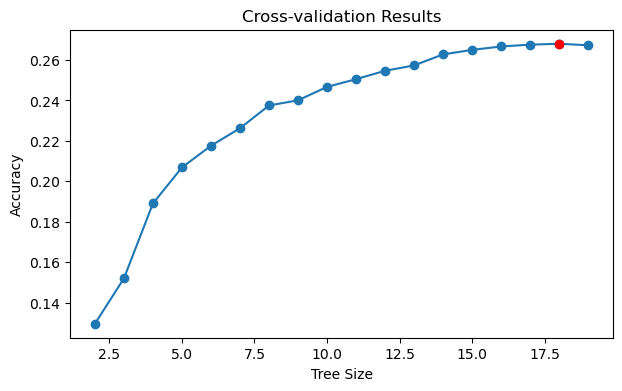

In [163]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 20)}  
cv_gaming_anxiety = GridSearchCV(tree_gaming_anxiety, params, cv=20)
cv_gaming_anxiety.fit(X_train, y_train)
cv_results = cv_gaming_anxiety.cv_results_

# find the best score for max leaf nodes
best_size = cv_gaming_anxiety.best_params_['max_leaf_nodes']
best_score = cv_gaming_anxiety.best_score_

# plot results of cross-validation
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_max_leaf_nodes"].data, cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [164]:
# fit pruned decision tree model
pruned_tree_gaming_anxiety = DecisionTreeRegressor(max_leaf_nodes=best_size, random_state=1)
pruned_tree_gaming_anxiety.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

In [165]:
pruned_tree_summary = export_text(pruned_tree_gaming_anxiety, feature_names=X_train.columns.tolist())
print(pruned_tree_summary)

|--- SWL3 <= 3.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN5 <= 1.50
|   |   |   |--- SWL2 <= 1.50
|   |   |   |   |--- value: [8.23]
|   |   |   |--- SWL2 >  1.50
|   |   |   |   |--- value: [5.21]
|   |   |--- SPIN5 >  1.50
|   |   |   |--- SWL3 <= 1.50
|   |   |   |   |--- value: [10.02]
|   |   |   |--- SWL3 >  1.50
|   |   |   |   |--- SPIN5 <= 3.50
|   |   |   |   |   |--- value: [6.75]
|   |   |   |   |--- SPIN5 >  3.50
|   |   |   |   |   |--- value: [10.16]
|   |--- SPIN13 >  0.50
|   |   |--- SPIN14 <= 3.50
|   |   |   |--- SWL3 <= 2.50
|   |   |   |   |--- value: [9.51]
|   |   |   |--- SWL3 >  2.50
|   |   |   |   |--- value: [7.41]
|   |   |--- SPIN14 >  3.50
|   |   |   |--- SPIN13 <= 3.50
|   |   |   |   |--- value: [11.15]
|   |   |   |--- SPIN13 >  3.50
|   |   |   |   |--- value: [15.63]
|--- SWL3 >  3.50
|   |--- SPIN13 <= 0.50
|   |   |--- SPIN5 <= 1.50
|   |   |   |--- SWL3 <= 5.50
|   |   |   |   |--- value: [3.51]
|   |   |   |--- SWL3 >  5.50
|   |   |   |   |--

In [166]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned = pruned_tree_gaming_anxiety.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned*100))

Accuracy: 25.44%


### Random Forest Tuning

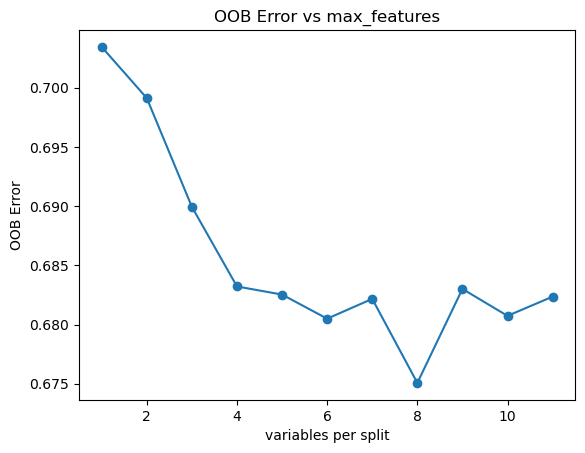

In [167]:
# Create plot to find optimal max_features
rf_gaming_anxiety = RandomForestRegressor(n_estimators=200, oob_score=True, random_state=1)
oob_errors = []

for n in range(1, 12):
    rf_gaming_anxiety.set_params(max_features=n)
    
    rf_gaming_anxiety.fit(X_train, y_train)
    oob_error = 1 - rf_gaming_anxiety.oob_score_
    oob_errors.append(oob_error)

# plot error vs max_features
plt.plot(range(1, 12), oob_errors, marker='o')
plt.xlabel("variables per split")
plt.ylabel("OOB Error")
plt.title("OOB Error vs max_features")
plt.show()